In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

In [6]:
df = pd.read_csv('https://raw.githubusercontent.com/malaikaaltaf48/EDA-feature-engineering-pipeline/refs/heads/main/train.csv')

In [ ]:
# EDA — Missing Values & Outliers
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})

missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
missing_df

,Missing Count,Missing %
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


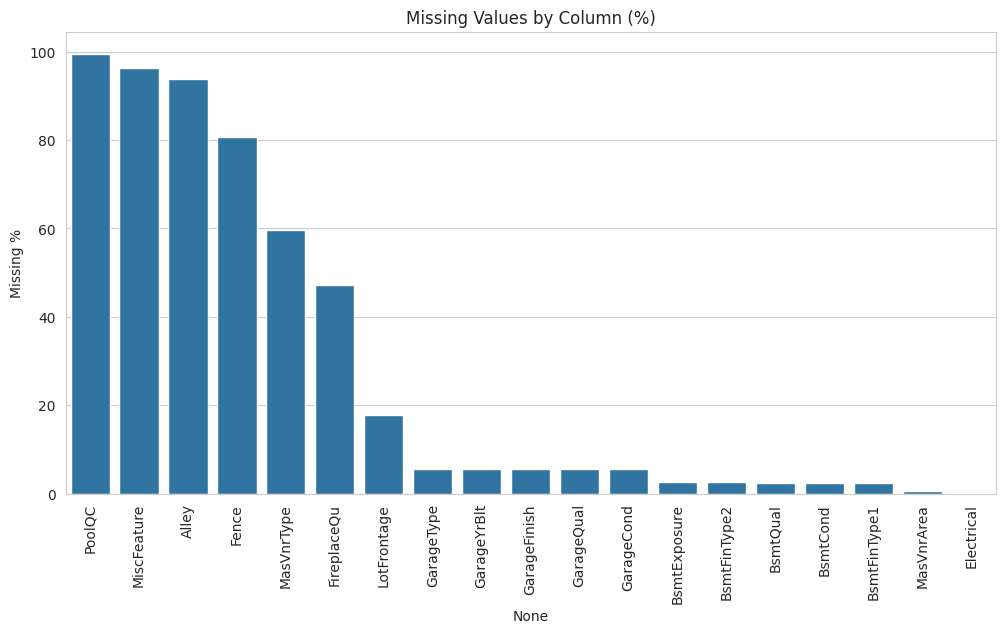

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=missing_df.index, y=missing_df['Missing %'])
plt.xticks(rotation=90)
plt.title("Missing Values by Column (%)")
plt.ylabel("Missing %")
plt.show()

In [ ]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']

for col in none_cols:
    df[col] = df[col].fillna("None")

In [ ]:
zero_cols = ['GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
             'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageArea', 'GarageCars']

for col in zero_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

In [ ]:
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

In [ ]:
remaining_missing = df.columns[df.isnull().any()]
print("Columns still with missing values:", list(remaining_missing))

for col in remaining_missing:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

Columns still with missing values: ['Electrical']


In [ ]:
print("Total missing values now:", df.isnull().sum().sum())

Total missing values now: 0


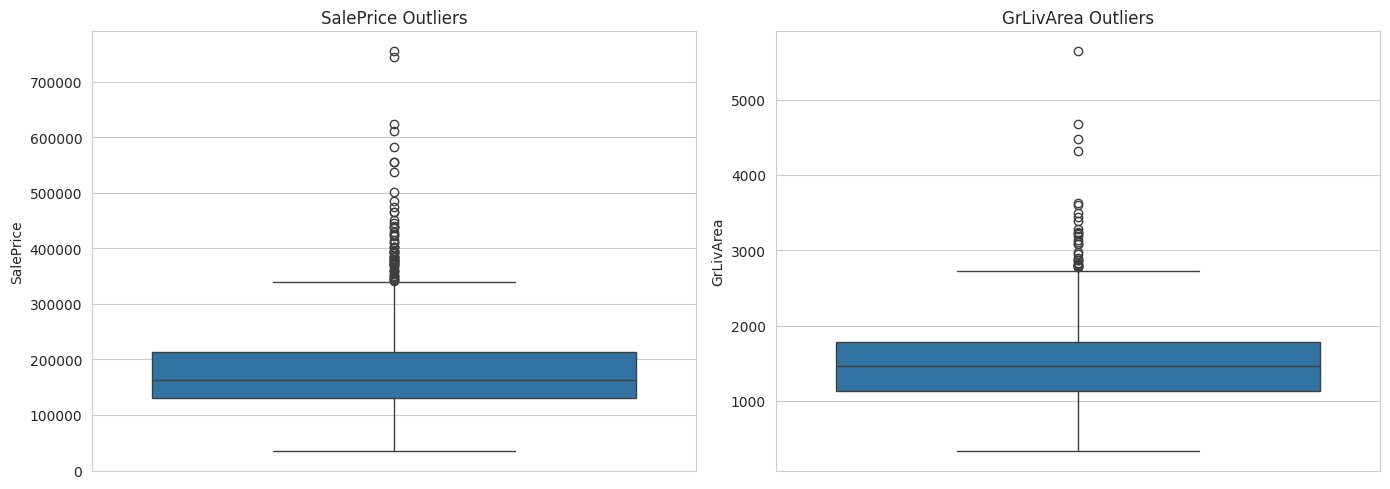

In [ ]:
#Outliers Detect & Neutralize
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(y=df['SalePrice'], ax=axes[0])
axes[0].set_title("SalePrice Outliers")

sns.boxplot(y=df['GrLivArea'], ax=axes[1])
axes[1].set_title("GrLivArea Outliers")

plt.tight_layout()
plt.show()

In [ ]:
def get_iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

lower, upper = get_iqr_bounds(df['GrLivArea'])
print(f"GrLivArea bounds: {lower:.2f} to {upper:.2f}")

outlier_count = ((df['GrLivArea'] < lower) | (df['GrLivArea'] > upper)).sum()
print(f"Number of outliers in GrLivArea: {outlier_count}")

GrLivArea bounds: 158.62 to 2747.62
Number of outliers in GrLivArea: 31


In [ ]:
numeric_cols_to_cap = ['GrLivArea', 'LotArea', 'TotalBsmtSF', '1stFlrSF', 'SalePrice']

for col in numeric_cols_to_cap:
    lower, upper = get_iqr_bounds(df[col])
    df[col] = np.clip(df[col], lower, upper)
    print(f"{col} capped between {lower:.2f} and {upper:.2f}")

GrLivArea capped between 158.62 and 2747.62
LotArea capped between 1481.50 and 17673.50
TotalBsmtSF capped between 42.00 and 2052.00
1stFlrSF capped between 118.12 and 2155.12
SalePrice capped between 3937.50 and 340037.50


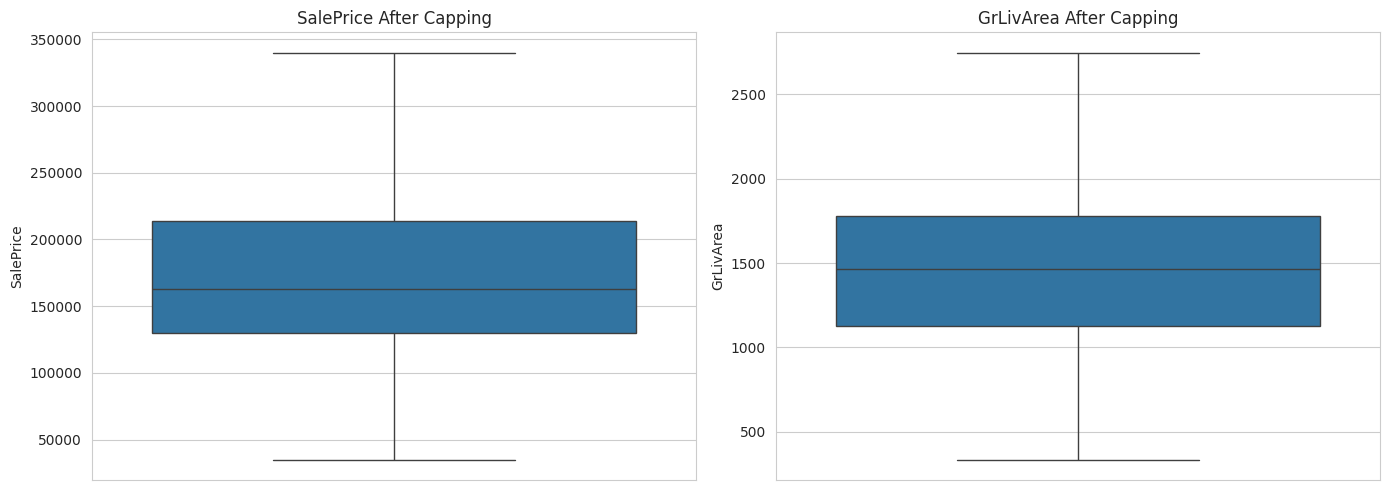

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(y=df['SalePrice'], ax=axes[0])
axes[0].set_title("SalePrice After Capping")

sns.boxplot(y=df['GrLivArea'], ax=axes[1])
axes[1].set_title("GrLivArea After Capping")

plt.tight_layout()
plt.show()

In [ ]:
# Feature Engineering
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

In [ ]:
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

In [ ]:
df['TotalBathrooms'] = (df['FullBath'] + (0.5 * df['HalfBath']) +
                          df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath']))

In [ ]:
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

In [ ]:
print('RemodAge' in df.columns)

True


In [ ]:
df['IsNew'] = (df['YearBuilt'] == df['YrSold']).astype(int)

In [ ]:
new_features = ['TotalSF', 'HouseAge', 'TotalBathrooms', 'RemodAge', 'IsNew']
df[new_features].describe()

,TotalSF,HouseAge,TotalBathrooms,RemodAge,IsNew
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,2554.265411,36.547945,2.210616,22.950000,0.043836
std,755.549717,30.250152,0.785399,20.640653,0.204799
min,376.000000,0.000000,1.000000,-1.000000,0.000000
25%,2009.500000,8.000000,2.000000,4.000000,0.000000
50%,2474.000000,35.000000,2.000000,14.000000,0.000000
75%,3004.000000,54.000000,2.500000,41.000000,0.000000
max,6272.125000,136.000000,6.000000,60.000000,1.000000


In [ ]:
correlations = df[new_features + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)
print(correlations)

SalePrice         1.000000
TotalSF           0.821488
TotalBathrooms    0.658351
IsNew             0.240695
RemodAge         -0.554206
HouseAge         -0.569407
Name: SalePrice, dtype: float64


In [ ]:
# Categorical Encoding
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Total categorical columns: {len(categorical_cols)}")
print(categorical_cols)

Total categorical columns: 43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [ ]:
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

In [ ]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Shape before encoding:", df.shape)
print("Shape after encoding:", df_encoded.shape)

Shape before encoding: (1460, 85)
Shape after encoding: (1460, 265)


In [ ]:
df_encoded.dtypes.value_counts()

,count
bool,223
int64,33
float64,9


In [ ]:
# Multicollinearity Check
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr().abs()
corr_matrix.shape

(42, 42)

In [ ]:
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

In [ ]:
high_corr_pairs = []
for col in upper_triangle.columns:
    for row in upper_triangle.index:
        value = upper_triangle.loc[row, col]
        if pd.notna(value) and value > 0.80:
            high_corr_pairs.append((row, col, round(value, 3)))

high_corr_pairs_df = pd.DataFrame(high_corr_pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])
high_corr_pairs_df.sort_values('Correlation', ascending=False)

,Feature 1,Feature 2,Correlation
6,YearBuilt,HouseAge,0.999
7,YearRemodAdd,RemodAge,0.998
2,GarageCars,GarageArea,0.882
4,GrLivArea,TotalSF,0.865
1,GrLivArea,TotRmsAbvGrd,0.836
5,SalePrice,TotalSF,0.821
3,OverallQual,SalePrice,0.817
0,TotalBsmtSF,1stFlrSF,0.807


In [ ]:
target_corr = numeric_df.corr()['SalePrice'].abs()

cols_to_drop = set()
for f1, f2, _ in high_corr_pairs:
    if f1 == 'SalePrice' or f2 == 'SalePrice':
        continue
    if target_corr[f1] < target_corr[f2]:
        cols_to_drop.add(f1)
    else:
        cols_to_drop.add(f2)

print("Columns to drop due to multicollinearity:", cols_to_drop)

Columns to drop due to multicollinearity: {'GarageArea', 'GrLivArea', 'YearRemodAdd', '1stFlrSF', 'TotRmsAbvGrd', 'YearBuilt'}


In [ ]:
cols_to_drop_existing = [c for c in cols_to_drop if c in df_encoded.columns]
df_encoded = df_encoded.drop(columns=cols_to_drop_existing)
print("Final shape after removing multicollinearity:", df_encoded.shape)

Final shape after removing multicollinearity: (1460, 259)


In [ ]:
print("Final dataset shape:", df_encoded.shape)
print("\nMissing values remaining:", df_encoded.isnull().sum().sum())
print("\nColumn data types:")
print(df_encoded.dtypes.value_counts())

Final dataset shape: (1460, 259)

Missing values remaining: 0

Column data types:
bool       223
int64       29
float64      7
Name: count, dtype: int64


In [ ]:
df_encoded.to_csv("cleaned_house_prices.csv", index=False)
print("Saved successfully!")

Saved successfully!


In [ ]:
from google.colab import files
files.download("cleaned_house_prices.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("=" * 50)
print("PROJECT 1 SUMMARY")
print("=" * 50)
print(f"Original dataset shape: {df.shape}")
print(f"Final cleaned dataset shape: {df_encoded.shape}")
print(f"\nMissing values handled: Yes (None/0 fill for 'not applicable' NaNs, group-median for LotFrontage, mode/median for remaining)")
print(f"Outliers neutralized via: IQR-based Winsorization (clip, not deletion)")
print(f"New features engineered: TotalSF, HouseAge, TotalBathrooms, RemodAge, IsNew (5 features)")
print(f"Categorical encoding: One-Hot Encoding (not Label Encoding, to avoid false ordinal distance)")
print(f"Multicollinearity removed: {len(cols_to_drop_existing)} redundant columns dropped")

PROJECT 1 SUMMARY
Original dataset shape: (1460, 85)
Final cleaned dataset shape: (1460, 259)

Missing values handled: Yes (None/0 fill for 'not applicable' NaNs, group-median for LotFrontage, mode/median for remaining)
Outliers neutralized via: IQR-based Winsorization (clip, not deletion)
New features engineered: TotalSF, HouseAge, TotalBathrooms, RemodAge, IsNew (5 features)
Categorical encoding: One-Hot Encoding (not Label Encoding, to avoid false ordinal distance)
Multicollinearity removed: 6 redundant columns dropped
